
## Summary of the Uncertainty Prediction Modeling with a CNN:

In this solution we will train a Convolutional Neural Network (CNN) model to predict astrophysical parameters (T_eff, log_g, Fe_H) along with their associated uncertainties.
Here are some key steps to do this:

### 1.  Download and Loading the Data:

We first download the spectral data and corresponding labels (astrophysical parameters) from the Hugging Face Hub, saved as numpy files and stored in the notebook file directory. The dataset contains more labels, but we filtered it to have only the ones we need  i.e. `t_eff`, `log_g`, and `fe_h`.

### 2. Data Preprocessing and Normalization

The data is first normalised to ensure standard scaling throughout. This is crucial step, called data preprocessing, that we do before feeding data into the neural network. It helps stabilize and speed up the training process. The normalization parameters (ranges) are also stored to allow for denormalization of predictions back to physical units later.

### 3. Data Conversion and DataLoaders

The normalized NumPy arrays are converted into  tensors to be campatible to use in Pytorch, as Pytorch works with tensors. The dataset is then split into training, validation, and test set. PyTorch `DataLoaders` are created for each set, enabling efficient batch processing during training and evaluation. Otherwise, the training takes to much gpu space. This step is crucial for convergence provided limited gpu credits.

### 4. UncertaintyCNN Model:

We defined a custom Uncertainty CNN model. This model uses a `TinyCNN` as its backbone but is modified to output twice the number of labels: one set for the predicted astrophysical parameters and another set for the logarithm of the uncertainties (`log_sigma`). The `log_sigma` is then exponentially transformed to `sigma` (standard deviation).

### 5. Negative Log-Likelihood (NLL):

WE used Negative Log-Likelihood (NLL) as the loss function.

### 6. Model Training

The Uncertainty CNN model is trained using the NLL loss function. Training is performed on a GPU for faster computation. An early stopping mechanism is implemented, based on the validation loss, to prevent overfitting and save the best performing model weights.

### 7. Loss Visualization

Plots of the training and validation NLL losses over epochs are generated, to  help visualize the learning progress and identify if the model is learning effectively and generalizing well to unseen data.

### 8. Test Set Evaluation and Denormalization

After training, the best-performing model is loaded and evaluated on the held-out test set. The model makes predictions (parameters and uncertainties), which are then denormalized back.

### 9. Visualization of Predictions and Uncertainties

### 10. Correlation Analysis

### 11. The pull distribution

Summary of the whole solution:

 ### Step 1: Download and load data

In [49]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="simbaswe/galah4", filename="labels.npy", repo_type="dataset", local_dir=".")
hf_hub_download(repo_id="simbaswe/galah4", filename="spectra.npy", repo_type="dataset", local_dir=".")

#You can load the data via
spectra = np.load("spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load("labels.npy")
# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

### Step 2: Imports

In [50]:
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split


import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
from helper import normalize, denormalize, denormalize_std, train_model, get_normalized_data, evaluate_model

from model_examples import TinyCNN


In [51]:
print(open('model_examples.py').read())

import torch.nn as nn


class TinyCNN(nn.Module):
    def __init__(self, nLabels):
        super(TinyCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv1d(1, 10, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
            nn.Conv1d(10, 20, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(20),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
            nn.Conv1d(20, 40, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(40),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),
            nn.Conv1d(40, 10, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Dropout(0.1),
            nn.AvgPool1d(2),
            nn.Conv1d(10, 12, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(12),
            nn.Dropout(0.2),
            nn.Conv1d(12, 10, kernel_size=1),
            nn.Dropout(0.2),


 ### Step 3: Preprocessing and Normalize Data

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data('.')

print(f"Spectra shape:  {spectra.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Label names:    {labelNames}")
print(f"Spectra length: {spectra_length}")
print(f"N labels:       {n_labels}")
print(f"Ranges:         {ranges}")

Spectra shape:  (8914, 16384)
Labels shape:   (8914, 3)
Label names:    ['t_eff', 'log_g', 'fe_h']
Spectra length: 16384
N labels:       3
Ranges:         [[ 4.64625725e+03  2.43369770e+00 -7.41016626e-01]
 [ 6.12287556e+03  4.58456130e+00  2.18186857e-01]]


### Step 4: Conversion into Tensors and Creating the DataLoaders for efficient training

In [54]:
# Hyperparameters for the model training
learning_rate = 2e-4
batch_size = 32
num_epochs = 100
patience = 10
train_fraction = 0.7
val_fraction = 0.15

# Convert numpy arrays to PyTorch tensors for model input
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

# Split the dataset into training, validation, and test sets
total_samples = len(spectra_tensor)
train_size = int(train_fraction * total_samples)
val_size = int(val_fraction * total_samples)
test_size = total_samples - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    TensorDataset(spectra_tensor, labels_tensor),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # Ensure reproducible data split
)

# Create DataLoaders for efficient batch processing during training and evaluation
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Print the sizes of the created datasets
print(f"Training:   {len(train_dataset)} stars")
print(f"Validation: {len(val_dataset)} stars")
print(f"Test:       {len(test_dataset)} stars")

Training:   6239 stars
Validation: 1337 stars
Test:       1338 stars


### Step 5: Model for Uncertainty prediction

In [55]:
class UncertaintyCNN(nn.Module):
    def __init__(self, n_labels):
        super(UncertaintyCNN, self).__init__()

        # We use TinyCNN as the backbone but modify the output to predict both values and uncertainties
        self.backbone = TinyCNN(n_labels * 2) # Output dimension is n_labels for predictions + n_labels for log(sigma)

    def forward(self, x):
        # Pass the input through the backbone CNN
        output = self.backbone(x)

        # Split the output into predictions and log of uncertainties (log_sigma)
        # The first n_labels outputs are the predictions, the next n_labels are log_sigma
        predictions   = output[:, :n_labels]
        log_sigma     = output[:, n_labels:]

        # Convert log_sigma to actual standard deviation (sigma) using exponential function
        # This ensures sigma is always positive, as uncertainties must be positive
        sigma = torch.exp(log_sigma)

        return predictions, sigma

# Create an instance of the UncertaintyCNN model
# n_labels is the number of astrophysical parameters we are predicting (e.g., t_eff, log_g, fe_h)
model = UncertaintyCNN(n_labels)
print(model) # Print the model's architecture for review

UncertaintyCNN(
  (backbone): TinyCNN(
    (model): Sequential(
      (0): Conv1d(1, 10, kernel_size=(5,), stride=(1,))
      (1): ReLU()
      (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): Dropout(p=0.1, inplace=False)
      (4): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (5): Conv1d(10, 20, kernel_size=(5,), stride=(1,))
      (6): ReLU()
      (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): Dropout(p=0.1, inplace=False)
      (9): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (10): Conv1d(20, 40, kernel_size=(5,), stride=(1,))
      (11): ReLU()
      (12): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (13): Dropout(p=0.1, inplace=False)
      (14): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
      (15): Conv1d(40, 10, kernel_size=(1,), stride=(1,))
      (16): ReLU()
      (17): BatchNorm1d(10, eps=1e-0

### Step 6: The Objective Function_Negative Log-Likelihood for uncertainty prediction

In [56]:
def nll_loss(inputs, labels, model):
    """
    Computes the Negative Log-Likelihood (NLL) loss for uncertainty estimation.

    Parameters
    ----------
    inputs : torch.Tensor
        Input spectra batch
    labels : torch.Tensor
        True labels (t_eff, log_g, fe_h)
    model : torch.nn.Module
        The uncertainty CNN model

    Returns
    -------
    torch.Tensor
        The mean NLL loss over the batch
    """
    predictions, sigma = model(inputs)

    # NLL formula: log(σ) + (prediction - true_value)² / (2σ²)
    nll = torch.log(sigma) + (predictions - labels)**2 / (2 * sigma**2)

    return nll.mean()

In [57]:
# Check if a GPU (CUDA) is available, otherwise use the CPU for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move the model to the selected device (GPU or CPU) to perform computations there
model = model.to(device)

# Train the model using the pre-defined helper function 'train_model'
# This function handles the training loop, validation, and early stopping
train_losses, val_losses, best_model = train_model(
    model,            # The neural network model to be trained
    train_loader,     # DataLoader for the training dataset
    val_loader,       # DataLoader for the validation dataset
    nll_loss,         # The negative log-likelihood loss function
    learning_rate,    # The learning rate for the optimizer
    num_epochs,       # The maximum number of training epochs
    patience,         # Number of epochs to wait for improvement before early stopping
    device            # The device (GPU/CPU) to perform training on
)

Training on: cuda
Epoch [1/100], Step [190/195], Loss: -1.2191
Epoch [1/100], Train Loss: -0.8391, Val Loss: -1.3571, Time: 2.33 seconds
Epoch [2/100], Step [190/195], Loss: -1.4347
Epoch [2/100], Train Loss: -1.3733, Val Loss: -1.6437, Time: 2.24 seconds
Epoch [3/100], Step [190/195], Loss: -1.6507
Epoch [3/100], Train Loss: -1.5296, Val Loss: -1.7827, Time: 2.25 seconds
Epoch [4/100], Step [190/195], Loss: -1.7202
Epoch [4/100], Train Loss: -1.6351, Val Loss: -1.8912, Time: 2.38 seconds
Epoch [5/100], Step [190/195], Loss: -1.6736
Epoch [5/100], Train Loss: -1.7210, Val Loss: -1.8162, Time: 2.46 seconds
Epoch [6/100], Step [190/195], Loss: -1.8545
Epoch [6/100], Train Loss: -1.7714, Val Loss: -2.0337, Time: 2.25 seconds
Epoch [7/100], Step [190/195], Loss: -1.7375
Epoch [7/100], Train Loss: -1.8054, Val Loss: -2.0112, Time: 2.25 seconds
Epoch [8/100], Step [190/195], Loss: -1.8305
Epoch [8/100], Train Loss: -1.8759, Val Loss: -1.9543, Time: 2.25 seconds
Epoch [9/100], Step [190/195],

### Step 8: Visualizing Training and Validation Loss

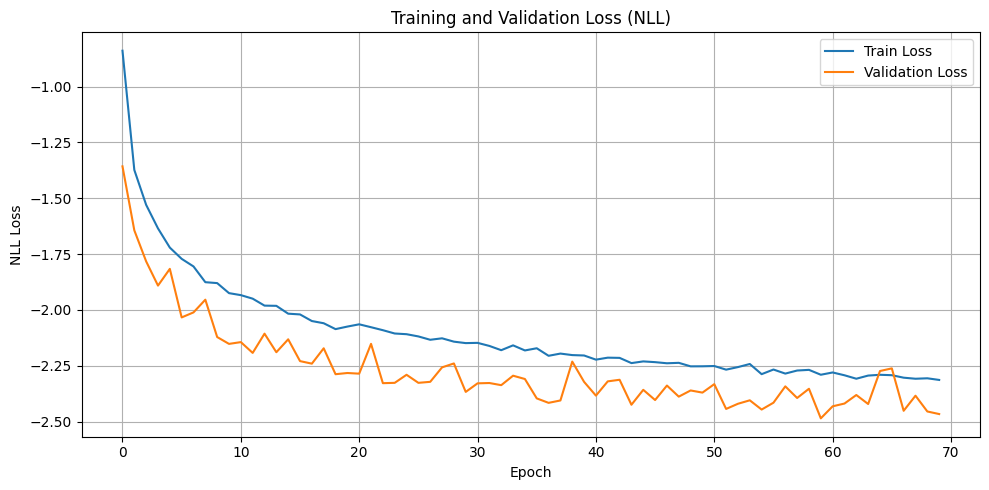

In [58]:
plt.figure(figsize=(10, 5)) # Create a new figure with a specified size
plt.plot(train_losses, label='Train Loss') # Plot the training losses
plt.plot(val_losses, label='Validation Loss') # Plot the validation losses
plt.xlabel('Epoch') # Set the x-axis label
plt.ylabel('NLL Loss') # Set the y-axis label
plt.title('Training and Validation Loss (NLL)') # Set the title of the plot
plt.legend() # Display the legend to differentiate between train and validation losses
plt.grid(True) # Add a grid to the plot for better readability
plt.tight_layout() # Adjust plot parameters for a tight layout


Both losses goes down with increasing epochs, which is a good sign of effective training, and showing model is not under or over-fitting as well.

### Step 9: Checking the model on the Test Set

In [59]:
# Load the best model weights saved during training
model.load_state_dict(best_model)
model.to(device)

# Set the model to evaluation mode (disables dropout, uses running stats for BatchNorm)
model.eval()

# Initialize lists to store predictions, sigmas (uncertainties), and true labels
all_predictions = []
all_sigmas = []
all_true_labels = []

# Disable gradient calculations for inference to save memory and speed up computation
with torch.no_grad():
    # Iterate through the test data in batches
    for batch_spectra, batch_labels in test_loader:
        # Move input spectra to the device (GPU/CPU) and add a channel dimension for Conv1D
        batch_spectra = batch_spectra.to(device).unsqueeze(1)

        # Get predictions and uncertainties (sigma) from the model
        predictions, sigma = model(batch_spectra)

        # Move results back to CPU and append to lists
        all_predictions.append(predictions.cpu())
        all_sigmas.append(sigma.cpu())
        all_true_labels.append(batch_labels)

# Concatenate all batch results into single NumPy arrays
all_predictions = torch.cat(all_predictions).numpy()
all_sigmas      = torch.cat(all_sigmas).numpy()
all_true_labels = torch.cat(all_true_labels).numpy()

# Denormalize predictions and true labels back to their original physical scales
all_predictions = denormalize(all_predictions, ranges)
all_sigmas      = denormalize_std(all_sigmas, ranges) # Denormalize standard deviation/uncertainty
all_true_labels = denormalize(all_true_labels, ranges)

print("Evaluation complete!")
print(f"Predictions shape: {all_predictions.shape}")
print(f"Sigmas shape:      {all_sigmas.shape}")
print(f"True labels shape: {all_true_labels.shape}")

Evaluation complete!
Predictions shape: (1338, 3)
Sigmas shape:      (1338, 3)
True labels shape: (1338, 3)


### Step 10: Visualizion of Predictions with Uncertainties

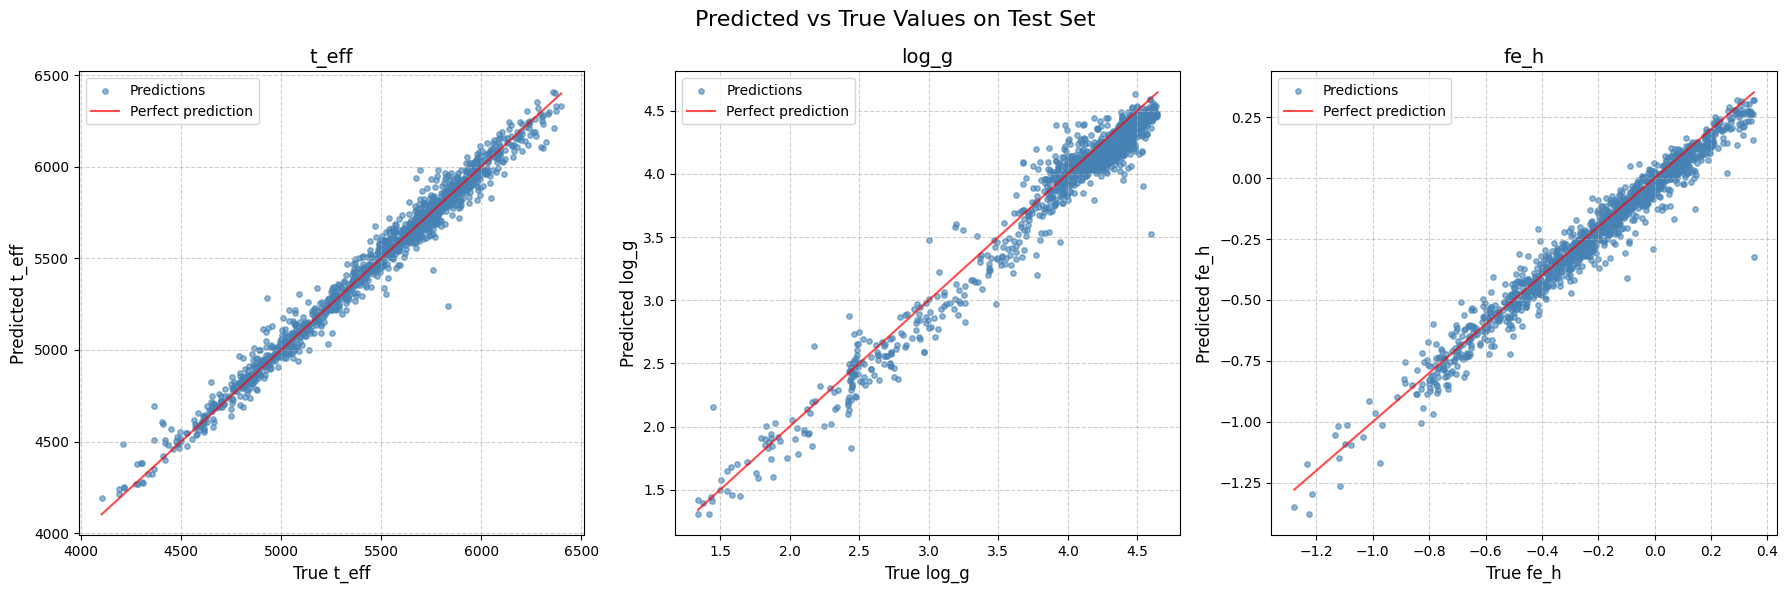

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Create a figure and a set of subplots (1 row, 3 columns)

for i, name in enumerate(labelNames):
    # Plot predicted vs true values for the current label
    axes[i].scatter(all_true_labels[:, i], all_predictions[:, i],
                    alpha=0.6, s=15, label='Predictions', color='steelblue') # Scatter plot with styling

    # Define the 'perfect prediction' line (where predicted = true)
    min_val = all_true_labels[:, i].min()
    max_val = all_true_labels[:, i].max()
    axes[i].plot([min_val, max_val], [min_val, max_val],
                 'r', alpha=0.7, label='Perfect prediction') # Plot the 1:1 line in red

    # Set labels, title, and legend for the current subplot
    axes[i].set_xlabel(f'True {name}', fontsize=12)
    axes[i].set_ylabel(f'Predicted {name}', fontsize=12)
    axes[i].set_title(f'{name}', fontsize=14)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability

# Set a main title for the entire figure
plt.suptitle('Predicted vs True Values on Test Set', fontsize=16)
plt.tight_layout() # Adjust layout to prevent labels/titles from overlapping
plt.show() # Display the plot

## Uncertainty Visualization.

We want to visualize the predicted uncertainty against the actual absolute error foir each astrophysical property herte, t_eff, log_g and fe_h, via three scatter plots for each. For each star, we will calculkate absolute difference between the predicted and true value i.e. error and then this the Actuak error will be plotted against our model´s prediction of error.

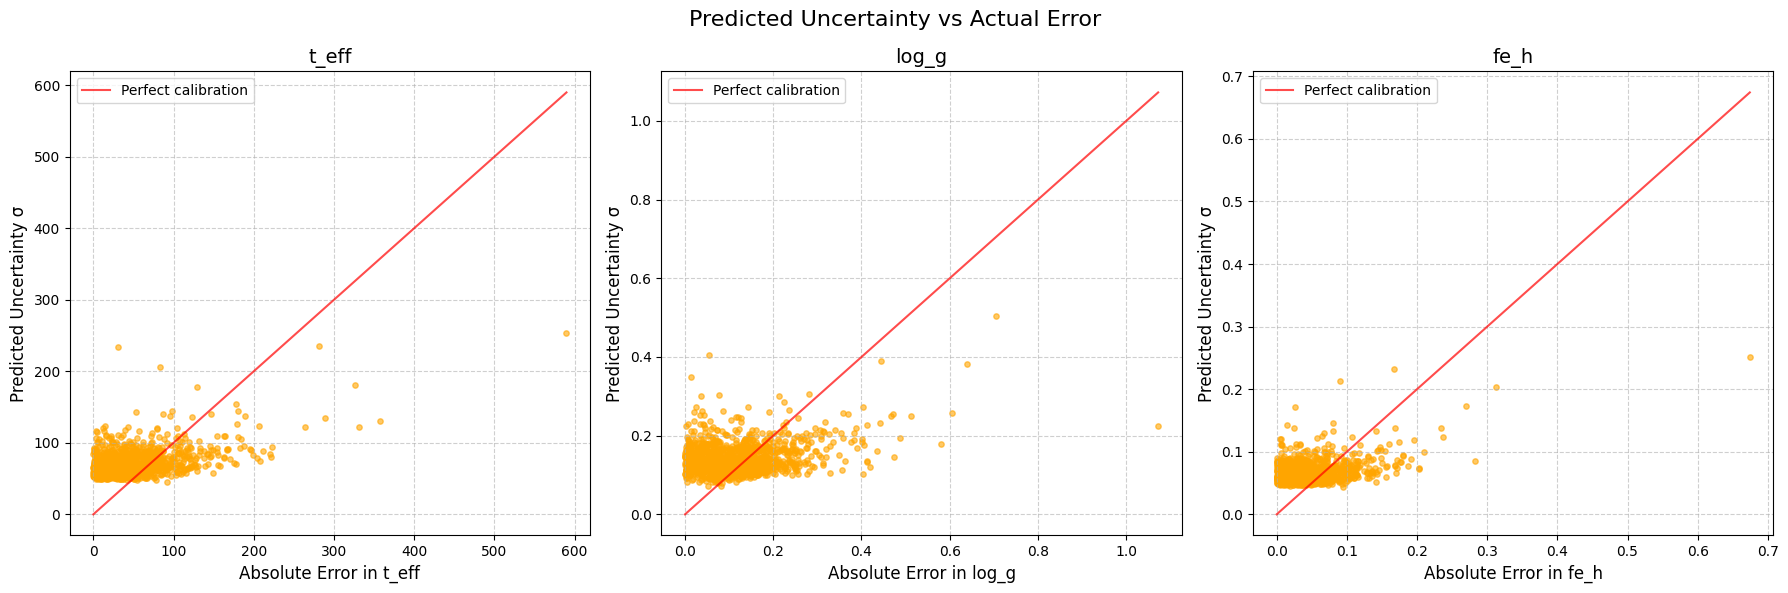

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, name in enumerate(labelNames):
    # compute absolute error for each star
    errors = np.abs(all_predictions[:, i] - all_true_labels[:, i])
    sigma  = all_sigmas[:, i]

    # plot uncertainty vs actual error
    axes[i].scatter(errors, sigma, alpha=0.6, s=15, color='orange')
    axes[i].set_xlabel(f'Absolute Error in {name}', fontsize=12)
    axes[i].set_ylabel(f'Predicted Uncertainty σ', fontsize=12)
    axes[i].set_title(f'{name}', fontsize=14)

    # perfect calibration line (sigma should equal error)
    max_val = max(errors.max(), sigma.max())
    axes[i].plot([0, max_val], [0, max_val], 'r', alpha=0.7, label='Perfect calibration')
    axes[i].legend(fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Predicted Uncertainty vs Actual Error', fontsize=16)
plt.tight_layout()


lets see where its concentrated

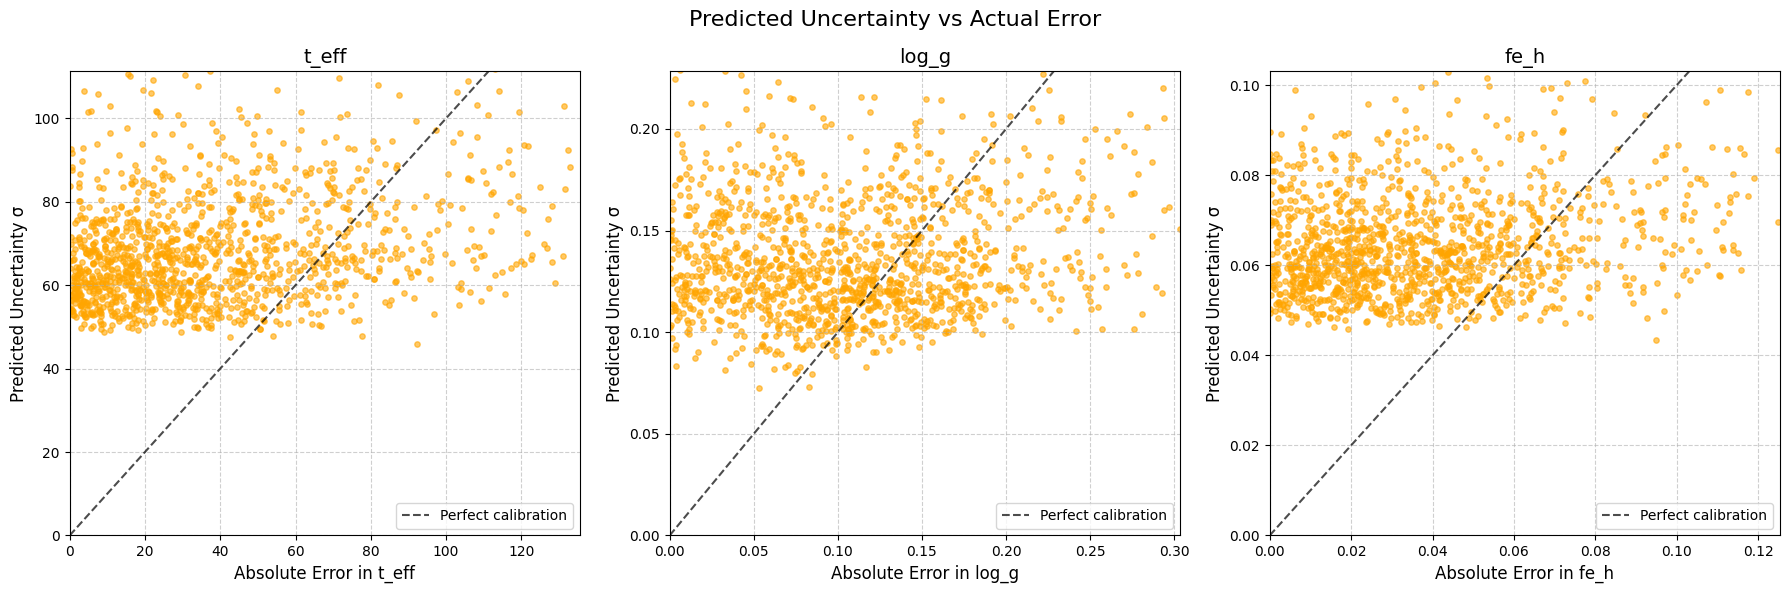

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, name in enumerate(labelNames):
    # compute absolute error for each star
    errors = np.abs(all_predictions[:, i] - all_true_labels[:, i])
    sigma  = all_sigmas[:, i]

    # plot uncertainty vs actual error
    axes[i].scatter(errors, sigma, alpha=0.6, s=15, color='orange')
    axes[i].set_xlabel(f'Absolute Error in {name}', fontsize=12)
    axes[i].set_ylabel(f'Predicted Uncertainty σ', fontsize=12)
    axes[i].set_title(f'{name}', fontsize=14)

    # Set x and y limits to focus on the most concentrated data (e.g., 95th percentile)
    error_upper_bound = np.percentile(errors, 95)
    sigma_upper_bound = np.percentile(sigma, 95)

    axes[i].set_xlim(0, error_upper_bound * 1.1)  # Add 10% buffer
    axes[i].set_ylim(0, sigma_upper_bound * 1.1)  # Add 10% buffer

    # perfect calibration line (sigma should equal error)
    max_val_for_line = max(error_upper_bound, sigma_upper_bound) * 1.1
    axes[i].plot([0, max_val_for_line], [0, max_val_for_line], 'k--', alpha=0.7, label='Perfect calibration')
    axes[i].legend(fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Predicted Uncertainty vs Actual Error', fontsize=16)
plt.tight_layout()
plt.show()

### Step 11: Calculate Correlation between Absolute Error and Predicted Uncertainty

In [63]:
print("Correlation between Absolute Error and Predicted Uncertainty:")
for i, name in enumerate(labelNames):
    errors = np.abs(all_predictions[:, i] - all_true_labels[:, i])
    sigma  = all_sigmas[:, i]
    correlation = np.corrcoef(errors, sigma)[0, 1]
    print(f"  {name}: {correlation:.4f}")

Correlation between Absolute Error and Predicted Uncertainty:
  t_eff: 0.4875
  log_g: 0.3068
  fe_h: 0.4416


This plot shows how well the model´s uncertainties reflects its actual prediction errors. The red line is reference line for ideal cases when both of them are equal.

The moderate values of correlation, shows that model´s predicted uncertainties generally increases with actual errors increasing, showing model´s appropriate perfromance for uncertainty predictions. However, it could be improved, as higher correlations reflects a model with strong prediction power.

### Step 12: Pull Distribution Analysis

The 'pull' is a metric often used in scientific measurements to assess the quality of uncertainties. It is defined as `(predicted_value - true_value) / predicted_uncertainty`. Ideally, if the predicted uncertainties are accurate and the errors are normally distributed, the pull distribution should be a Gaussian (normal distribution) with a mean of 0 and a standard deviation of 1. Deviations from this ideal indicate miscalibration of uncertainties.

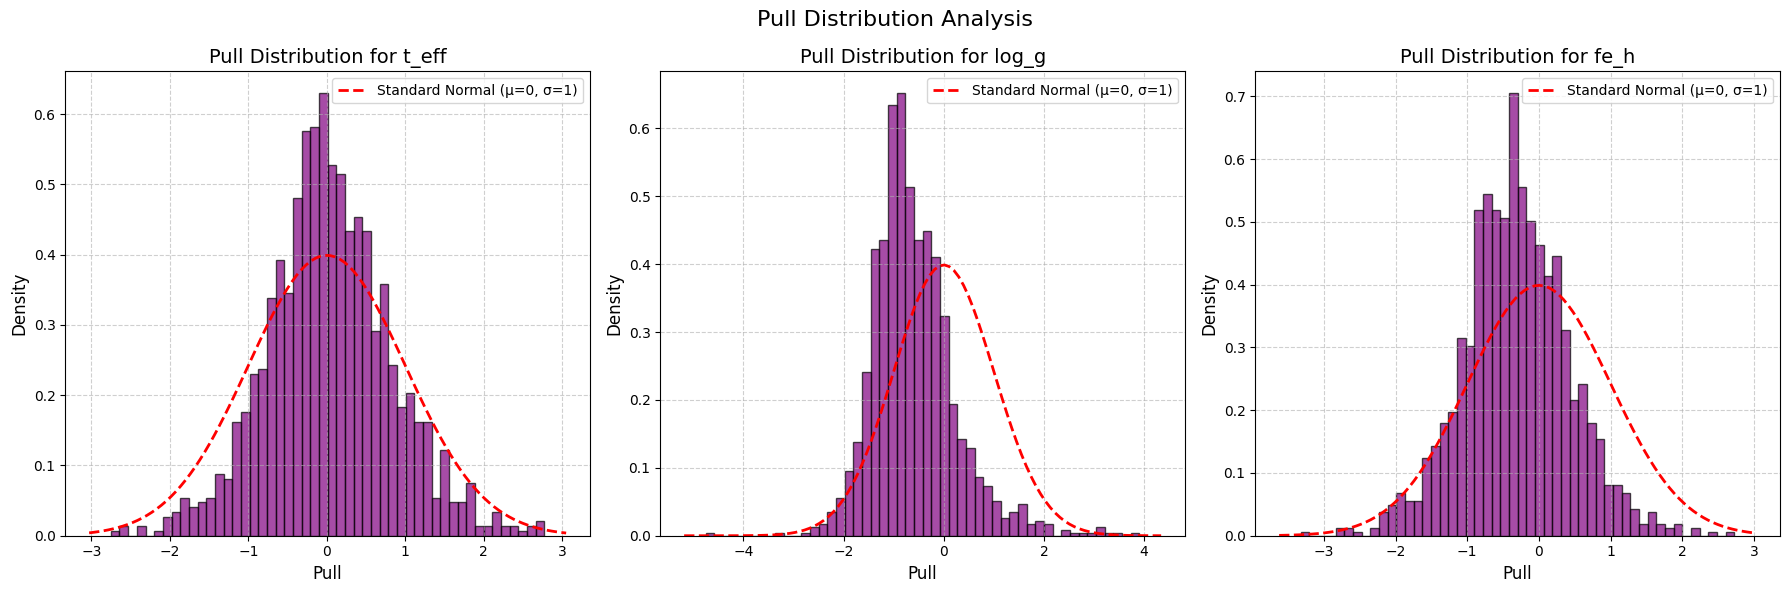

Mean and Standard Deviation of Pull Distribution:
  t_eff: Mean = 0.0341, Std Dev = 0.7976
  log_g: Mean = -0.6012, Std Dev = 0.8401
  fe_h: Mean = -0.3193, Std Dev = 0.7496


In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, name in enumerate(labelNames):
    # Calculate the 'pull' for each prediction
    # Pull = (prediction - true_value) / predicted_uncertainty
    pull = (all_predictions[:, i] - all_true_labels[:, i]) / all_sigmas[:, i]

    # Plot histogram of the pull distribution
    axes[i].hist(pull, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black')

    # Plot a standard normal distribution for comparison
    # This helps visualize if the pull distribution is well-calibrated
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*(x**2)) # Standard normal PDF
    axes[i].plot(x, p, 'r--', linewidth=2, label='Standard Normal (μ=0, σ=1)')

    axes[i].set_xlabel('Pull', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].set_title(f'Pull Distribution for {name}', fontsize=14)
    axes[i].legend(fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Pull Distribution Analysis', fontsize=16)
plt.tight_layout()
plt.show()

print("Mean and Standard Deviation of Pull Distribution:")
for i, name in enumerate(labelNames):
    pull = (all_predictions[:, i] - all_true_labels[:, i]) / all_sigmas[:, i]
    print(f"  {name}: Mean = {np.mean(pull):.4f}, Std Dev = {np.std(pull):.4f}")

The pull distribution analysis indicates that the model's uncertainties are not perfectly calibrated. For t_eff, the standard deviation is less than 1, suggesting potential overestimation of uncertainties. For log_g and fe_h, both the means deviate from 0 and standard deviations are less than 1, implying some miscalibration and possible underestimation or systematic shifts in the uncertainties. Overall, further refinement is needed for optimal uncertainty calibration.